In [1]:
### Cellule 3.1 ########

 
using Pkg
using DataFrames, CSV, Dates
using Statistics, LinearAlgebra
using JuMP, Gurobi
using Plots
using Printf
 #Bibliothèque utile pour certains calculs statistiques complémentaires
using StatsBase
  #Bibliothèque de sauvegarde/chargement de données au format JLD2
using JLD2
  #Interface bas niveau entre JuMP et les solveurs
using MathOptInterface

  #Alias pour alléger l'écriture dans la suite du code
const MOI = MathOptInterface

# Dossier de sortie des figures, tableaux et résultats du chapitre 3
OUTDIR = "outputs_chap3"
isdir(OUTDIR) || mkpath(OUTDIR)

 #Liste des actifs étudiés
TICKERS= ["AAPL", "MSFT", "AMZN", "GOOG", "META"]

#Nombre d'actifs
  N= length(TICKERS)

 #Richesse initiale
W0= 1.0

  #Nombre de jours de bourse dans une année
FREQ = 252

#Niveau de confiance utilisé pour la CVaR
  α= 0.95

  #Bornes de la grille du paramètre de pénalisation η
 η_min= 1e-2
η_max= 1e2

#Nombre de points dans la grille
   Kη= 200

# Construction d’une grille logarithmique pour η
η_grid= 10 .^ collect(range(log10(η_min), log10(η_max), length=Kη))

 #Affichage d’un résumé de la grille
println("Grille de η : premier = ", η_grid[1], ", dernier = ", η_grid[end], ", taille = ", length(η_grid))

Grille de η : premier = 0.010000000000000002, dernier = 100.0, taille = 200


In [5]:
#### Cellule 3.2 ###########

   #Nom du fichier contenant les prix historiques
  PRICE_FILE = "prices_tech.csv"

 #Vérification que le fichier existe
    @assert isfile(PRICE_FILE) "Fichier introuvable : $PRICE_FILE"

   #Lecture du fichier CSV
prices = CSV.read(PRICE_FILE, DataFrame)

  #Vérification de la présence de la colonne Date
    @assert "Date" in names(prices) "La colonne 'Date' est absente. Colonnes dispo : $(names(prices))"

#Conversion de la colonne Date si nécessaire
if !(eltype(prices.Date) <: Date)
    prices.Date = Date.(prices.Date)
end

    #Conservation des colonnes utiles : Date + actifs étudiés
      select!(prices, ["Date"; TICKERS]...)

#Tri des observations par ordre chronologique
sort!(prices, :Date)

# Affichage d’un aperçu des données importées
println("Aperçu du fichier prices :")
println(first(prices, 3))
println(last(prices, 3))
println("Nombre total de lignes : ", nrow(prices))

Aperçu du fichier prices :
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2015-01-02  24.2374  40.1536  15.426   26.2405    78.45
   2 │ 2015-01-05  23.5555  39.7826  15.1095  25.6935    77.19
   3 │ 2015-01-06  23.5575  39.1972  14.7645  25.098     76.15
3×6 DataFrame
 Row │ Date        AAPL     MSFT     AMZN     GOOG     META    
     │ Date        Float64  Float64  Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────
   1 │ 2025-12-29   273.76   487.1    232.07   314.39   658.69
   2 │ 2025-12-30   273.08   487.48   232.53   314.55   665.95
   3 │ 2025-12-31   271.86   483.62   230.82   313.8    660.09
Nombre total de lignes : 2766


In [7]:
#### Cellule 3.3 #####

#Vérification de l'absence de valeurs manquantes pour chaque actif
for tk in TICKERS
    miss = count(ismissing, prices[!, tk])
    @assert miss == 0 "Valeurs manquantes détectées dans $tk : $miss"
end

  #Vérification de la positivité des prix
    #(les prix d'actifs doivent être strictement positifs)
for tk in TICKERS
    @assert minimum(prices[!, tk]) > 0 "Prix non positifs détectés dans $tk"
end

  #Message de validation
println("Contrôles sur les prix : OK")

Contrôles sur les prix : OK


In [9]:
#### Cellule 3.4 #####

  # Fonction de calcul des rendements simples :
   #R[t] = P[t] / P[t-1] - 1
simple_returns(p::AbstractVector{<:Real}) =
    p[2:end] ./ p[1:end-1] .- 1.0

    # Fonction de calcul des log-rendements :
     #r[t]= log(P[t] / P[t-1])
     #Ces rendements sont additifs dans le temps et utilisés
     # en modélisation financière.
log_returns(p::AbstractVector{<:Real}) =
    log.(p[2:end] ./ p[1:end-1])

log_returns (generic function with 1 method)

In [11]:
######### Cellule 3.5 ###

   #Nombre d'observations temporelles
     T= nrow(prices)

# Initialisation des matrices de rendements :
#dimensions : (T-1) x N car on perd une observation
   R_simple = Matrix{Float64}(undef, T-1, N)
   R_log = Matrix{Float64}(undef, T-1, N)

 #Calcul des rendements pour chaque actif
for (j, tk) in enumerate(TICKERS)
    p = Float64.(prices[!, tk])
    R_simple[:, j] = simple_returns(p)
    R_log[:, j]    = log_returns(p)
end

# Dates associées aux rendements
dates_ret = prices.Date[2:end]

# Affichage des dimensions
println("Dimensions R_simple : ", size(R_simple))
println("Dimensions R_log    : ", size(R_log))

Dimensions R_simple : (2765, 5)
Dimensions R_log    : (2765, 5)


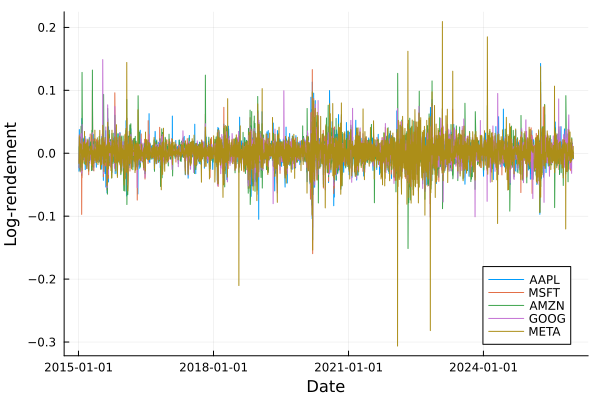

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 3\\outputs_chap3\\chap3_fig0_control_log_returns.png"

In [13]:
#### Cellule 3.6 ####

   #Création d’un graphique des log-rendements
     #pour vérifier visuellement la dynamique des actifs
p_ctrl= plot(
    dates_ret, R_log[:, 1],
    label = TICKERS[1],
    xlabel = "Date",
     ylabel= "Log-rendement",
    linewidth= 1
)

  #Ajout des autres actifs au graphique
for j in 2:N
    plot!(p_ctrl,
          dates_ret, R_log[:, j],
          label = TICKERS[j],
          linewidth = 1)
end

# Affichage
display(p_ctrl)

#Sauvegarde de la figure
savefig(p_ctrl, joinpath(OUTDIR, "chap3_fig0_control_log_returns.png"))

In [17]:
#### Cellule 3.7 #####

   #Construction d’un facteur de marché :
     #moyenne des log-rendements à chaque date
   R_mkt= vec(mean(R_log, dims=2))

#Taille de la fenêtre pour la volatilité glissante
  Kvol= 20

   # Initialisation du vecteur de volatilité
        vol= fill(NaN, length(R_mkt))

  #Calcul de la volatilité glissante (écart-type sur une fenêtre)
for t in Kvol:length(R_mkt)
    vol[t] = std(R_mkt[t-Kvol+1:t])
end

#Identification des indices valides (où la volatilité est définie)
  valid = .!isnan.(vol)

#Construction des données "contextuelles":
   #- rendements filtrés
   #- volatilité associée
   #- dates correspondantes
R_ctx= R_log[valid, :]
vol_ctx = vol[valid]
dates_ctx = dates_ret[valid]
R_mkt_ctx= R_mkt[valid]

  #Affichage des dimensions après filtrage
println("Dimensions après construction du contexte : ", size(R_ctx))
println("Nombre de dates retenues : ", length(dates_ctx))

Dimensions après construction du contexte : (2746, 5)
Nombre de dates retenues : 2746


In [19]:
#### Cellule 3.8 #####

  #Calcul des seuils de découpage de la volatilité
#en trois classes (quantiles 1/3 et 2/3)
  q1= quantile(vol_ctx, 1/3)
   q2= quantile(vol_ctx, 2/3)

# Fonction de classification en régimes :
   # 1 = faible volatilité
   # 2 = volatilité moyenne
   # 3 = forte volatilité
function regime(v, q1, q2)
    if v <= q1
        return 1
    elseif v <= q2
        return 2
    else
        return 3
    end
end

# Attribution d’un régime à chaque date
regimes = [regime(v, q1, q2) for v in vol_ctx]

# Affichage des seuils et de la répartition
println("Seuil q1 = ", q1)
println("Seuil q2 = ", q2)
println("Répartition des régimes : ", countmap(regimes))

Seuil q1 = 0.010517483639269062
Seuil q2 = 0.015506578581164185
Répartition des régimes : Dict(2 => 915, 3 => 915, 1 => 916)


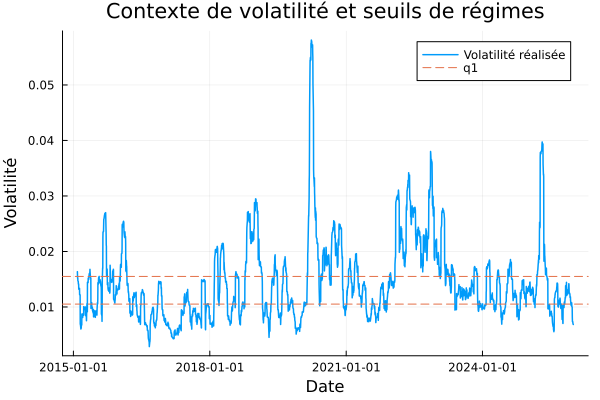

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 3\\outputs_chap3\\chap3_fig1_contexte.png"

In [21]:
#### Cellule 3.9 #######

#Tracé de la volatilité réalisée au cours du temps
p1 = plot(dates_ctx, vol_ctx,
    lw = 1.5,
    label = "Volatilité réalisée"
)

# Ajout des seuils de régimes (quantiles)
hline!([q1, q2],
       linestyle = :dash,
       label = ["q1" "q2"])

  #Étiquettes et titre
xlabel!("Date")
ylabel!("Volatilité")
title!("Contexte de volatilité et seuils de régimes")

# Affichage
display(p1)

# Sauvegarde de la figure
savefig(p1, joinpath(OUTDIR, "chap3_fig1_contexte.png"))

In [23]:
###### Cellule 3.10 ####

 #Estimation globale (toutes périodes confondues)

#Moyenne empirique des rendements (journalière)
 μ_daily= vec(mean(R_ctx, dims=1))

  #Matrice de covariance empirique (journalière)
  Σ_daily = cov(R_ctx, corrected=true)

 #Annualisation
  μ_ann= μ_daily .* FREQ
  Σ_ann = Σ_daily .* FREQ

# Initialisation des structures pour les estimations conditionnelles
    μ_cond_daily = Dict{Int, Vector{Float64}}()
    Σ_cond_daily = Dict{Int, Matrix{Float64}}()
    R_regime = Dict{Int, Matrix{Float64}}()

 #Estimation par régime de volatilité
for k in 1:3

    #Indices correspondant au régime k
    idx = findall(regimes .== k)
     #Sous-échantillon de rendements pour ce régime
     Rk= R_ctx[idx, :]
    #Stockage des données du régime
    R_regime[k] = Rk
     #Estimation de la moyenne conditionnelle
     μ_cond_daily[k] = vec(mean(Rk, dims=1))
    #Estimation de la covariance conditionnelle
    Σ_cond_daily[k] = cov(Rk, corrected=true)
end

# Affichage des informations
println("Estimation globale et conditionnelle terminée.")
for k in 1:3
    println("Régime ", k, " : ", size(R_regime[k], 1), " observations")
end

Estimation globale et conditionnelle terminée.
Régime 1 : 916 observations
Régime 2 : 915 observations
Régime 3 : 915 observations


In [25]:
#### Cellule 3.11 ####

#Fonction de résolution du problème moyenne-variance pénalisé :
    # min_x   η x'Σx - μ'x
    # sous contraintes :
       # sum(x) = 1
       # x_i >= 0 (portefeuille long-only)
#
  # Entrées :
     # μ_ann : rendement moyen annualisé
     # Σ_ann : matrice de covariance annualisée
     # η  : paramètre d’aversion au risque
#
  #Sorties :
     # xopt : poids optimaux
     # obj : valeur de la fonction objectif
     # er_ann: rendement espéré du portefeuille
     # status: statut du solveur
function solve_mv_penalized(μ_ann::Vector{Float64}, Σ_ann::Matrix{Float64}, η::Float64; silent::Bool=true)

      #Nombre d'actifs
    N= length(μ_ann)
     #Création du modèle d'optimisation
    model = Model(Gurobi.Optimizer)
    if silent
        set_silent(model)
    end
     #Variables de décision : poids du portefeuille
    @variable(model, x[1:N] >= 0.0)
    #Contrainte budgétaire
    @constraint(model, sum(x) == 1.0)

     #Fonction objectif quadratique :
    # compromis entre risque (variance) et rendement
    @objective(model, Min,
        η * sum(Σ_ann[i,j] * x[i] * x[j] for i in 1:N, j in 1:N) -
        sum(μ_ann[i] * x[i] for i in 1:N)
    )

    #Résolution
    optimize!(model)

      #Vérification du statut
    status = termination_status(model)
    if status != MOI.OPTIMAL
        error("solve_mv_penalized : échec optimisation, statut = $status")
    end

    #Extraction des résultats
    xopt = value.(x)
    obj = objective_value(model)
    er_ann = dot(μ_ann, xopt)

    return xopt, obj, er_ann, status
end

solve_mv_penalized (generic function with 1 method)

In [29]:
#### Cellule 3.12 ####

#Fonction de résolution du problème CVaR pénalisé :
  # min_x   η * CVaR_α(x) - μ'x
  # sous contraintes :
     #sum(x) = 1
     #x_i >= 0 (portefeuille long-only)
#
   #Entrées :
     # R: matrice N x M des scénarios de rendements
     # μ_ann : vecteur des rendements moyens annualisés
     # η: paramètre de pénalisation du risque
     # α : niveau de confiance de la CVaR
#
   # Sorties :
      # xopt: poids optimaux
      # obj: valeur de la fonction objectif
      # er_ann : rendement espéré annualisé
      # tval: proxy de la VaR journalière
      # cval: CVaR journalière
      # cvar_ann : CVaR annualisée (approximation)
      # status: statut du solveur
function solve_cvar_penalized(
    R::Matrix{Float64},
    μ_ann::Vector{Float64},
    η::Float64;
    α::Float64=0.95,
    silent::Bool=true,
    FREQ::Int=252
)

      #Dimensions :
      #N = nombre d'actifs
    #M = nombre de scénarios
    N, M = size(R)

    #Création du modèle d'optimisation
    model = Model(Gurobi.Optimizer)
    if silent
        set_silent(model)
    end

    #Variables de décision : poids du portefeuille
    @variable(model, x[1:N] >= 0.0)
     #Contrainte budgétaire
    @constraint(model, sum(x) == 1.0)

     #Variables auxiliaires de Rockafellar-Uryasev :
     #t : proxy de la VaR
     #z[m] : excès de perte au-delà de t dans le scénario m
       @variable(model, t)
       @variable(model, z[1:M] >= 0.0)

    #Contraintes scénario par scénario :
    #perte L_m = -x'r^(m)
    #z_m >= L_m - t
    for m in 1:M
        @constraint(model, z[m] >= -sum(R[i, m] * x[i] for i in 1:N) - t)
    end

    #Définition de la CVaR empirique (échelle journalière)
       CVaR= t+ (1.0 / ((1.0 - α) * M)) * sum(z)
    # Rendement espéré annualisé
    ER_ann = sum(μ_ann[i] * x[i] for i in 1:N)

    # Fonction objectif pénalisée :
     #compromis entre risque extrême et rendement
    @objective(model, Min, η * CVaR - ER_ann)

    #Résolution
    optimize!(model)

     #Vérification du statut du solveur
    status = termination_status(model)
    if status != MOI.OPTIMAL
        error("solve_cvar_penalized : échec optimisation, statut = $status")
    end

      #Extraction des résultats
        xopt= value.(x)
    obj= objective_value(model)
    tval= value(t)
    cval= value(CVaR)

    # Annualisation approximative de la CVaR
    cvar_ann= cval * FREQ

    return xopt, obj, dot(μ_ann, xopt), tval, cval, cvar_ann, status
end

solve_cvar_penalized (generic function with 1 method)

In [31]:
#### Cellule 3.13 ####

  #Fonction de calcul de la trajectoire de richesse
   #à partir des log-rendements du portefeuille :
    # W_t = W0 * exp(sum_{s<=t} r_s^p)
function wealth_path_log(rp::AbstractVector{<:Real}; W0::Real=1.0)
    return W0 .* exp.(cumsum(rp))
end

#Fonction de calcul empirique de la CVaR à partir d’un ensemble de scénarios
function empirical_cvar_from_scenarios(R::Matrix{Float64}, x::Vector{Float64}; α::Float64=0.95)

    #Calcul des pertes scénario par scénario
    losses= [-dot(x, R[:,m]) for m in 1:size(R,2)]
     #Tri croissant des pertes
    sort!(losses)
    #Indice correspondant au quantile α
    k= ceil(Int, α * length(losses))
     #CVaR = moyenne des pertes au-delà du quantile α
    return mean(losses[k:end])
end

empirical_cvar_from_scenarios (generic function with 1 method)

In [33]:
#### Cellule 3.14 ####

 #Matrice de scénarios pour la CVaR :
  #dimension N x M (actifs x scénarios)
R_cvar = Matrix(R_ctx')

# Tableau de résultats comparatifs pour chaque valeur de η
results_chap3 = DataFrame(
    η = Float64[],
    log10η = Float64[],
    ER_ann_static = Float64[],
    ER_ann_cvar = Float64[],
    ER_ann_ctx = Float64[],
    CVaR_ann_static = Float64[],
    CVaR_ann_cvar = Float64[],
    CVaR_ann_ctx = Float64[],
    Obj_static = Float64[],
    Obj_cvar = Float64[]
)

 #Matrices de stockage des poids optimaux :
    # -stratégie MV statique
    # -stratégie CVaR statique
    # -stratégie contextuelle par régime
     X_static = Matrix{Float64}(undef, Kη, N)
     X_cvar= Matrix{Float64}(undef, Kη, N)
    X_ctx_r1 = Matrix{Float64}(undef, Kη, N)
     X_ctx_r2 = Matrix{Float64}(undef, Kη, N)
     X_ctx_r3 = Matrix{Float64}(undef, Kη, N)

println("Résolution sur la grille de η...")

#Boucle sur la grille du paramètre η
for (kη, η) in enumerate(η_grid)

     #Affichage de progression tous les 20 points
    if kη % 20 == 0
        println("Progression : ", kη, "/", length(η_grid))
    end

    #Stratégie MV statique :
      #un seul portefeuille optimal est calculé sur l'ensemble des données
    x_static, obj_static, er_static, _ =
        solve_mv_penalized(μ_ann, Σ_ann, η; silent=true)
    X_static[kη, :] = x_static

#Stratégie CVaR statique :
    #un seul portefeuille optimal est calculé sur l'ensemble des scénarios
    x_cvar, obj_cvar, er_cvar, _, cvar_daily_cvar, cvar_ann_cvar, _ =
        solve_cvar_penalized(R_cvar, μ_ann, η; α=α, silent=true, FREQ=FREQ)
    X_cvar[kη, :] = x_cvar

    #Stratégie MV contextuelle :
      # un portefeuille optimal distinct est calculé pour chaque régime
    x1, _, _, _ =
        solve_mv_penalized(μ_cond_daily[1] .* FREQ, Σ_cond_daily[1] .* FREQ, η; silent=true)
    x2, _, _, _ =
        solve_mv_penalized(μ_cond_daily[2] .* FREQ, Σ_cond_daily[2] .* FREQ, η; silent=true)
    x3, _, _, _ =
        solve_mv_penalized(μ_cond_daily[3] .* FREQ, Σ_cond_daily[3] .* FREQ, η; silent=true)

    # Stockage des poids contextuels par régime
     X_ctx_r1[kη, :] = x1
    X_ctx_r2[kη, :] =x2
      X_ctx_r3[kη, :]= x3

    # Calcul des rendements réalisés de la stratégie contextuelle
    # à chaque date, on applique le portefeuille correspondant au régime observé
    rp_ctx = similar(R_mkt_ctx)
    for t in 1:length(regimes)
        if regimes[t] == 1
            rp_ctx[t] = dot(R_ctx[t, :], x1)
        elseif regimes[t] == 2
            rp_ctx[t] = dot(R_ctx[t, :], x2)
        else
            rp_ctx[t] = dot(R_ctx[t, :], x3)
        end
    end

    # Rendement annualisé de la stratégie contextuelle
       er_ctx_ann = mean(rp_ctx) * FREQ

    # Indicateur agrégé de la CVaR contextuelle :
       #on ne calcule pas ici la CVaR exacte de la stratégie dynamique date par date.
       #À la place, on construit un portefeuille moyen des trois régimes.
    #
       # [x1 x2 x3] forme une matrice N x 3 dont les colonnes sont les trois portefeuilles.
       # mean([x1 x2 x3], dims=2) calcule la moyenne ligne par ligne,
       # donc la moyenne des poids de chaque actif sur les trois régimes.
       # vec(...) transforme ensuite le résultat en un vecteur de taille N.
    #
       #Ainsi, vec(mean([x1 x2 x3], dims=2)) représente un portefeuille moyen
       #utilisé ici comme approximation simple pour évaluer le risque global.
    x_ctx_avg = vec(mean([x1 x2 x3], dims=2))
    cvar_ctx_daily = empirical_cvar_from_scenarios(R_cvar, x_ctx_avg; α=α)
    cvar_ctx_ann = cvar_ctx_daily * FREQ

    # CVaR empirique de la stratégie MV statique
    cvar_static_daily = empirical_cvar_from_scenarios(R_cvar, x_static; α=α)
    cvar_static_ann = cvar_static_daily * FREQ

    #Sauvegarde des résultats pour cette valeur de η
    push!(results_chap3, (
        η,
        log10(η),
        er_static,
        er_cvar,
        er_ctx_ann,
        cvar_static_ann,
        cvar_ann_cvar,
        cvar_ctx_ann,
        obj_static,
        obj_cvar
    ))
end

println("Résolution terminée.")

Résolution sur la grille de η...
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter LicenseID to value 2742579
Academic license - for non-commercial use only - expires 2026-11-20
Set parameter Username
Set parameter Licens

In [35]:
#### Cellule 3.15 #######

 #Portefeuille équipondéré (benchmark)
  xEW= fill(1.0 / N, N)

#Rendement espéré annualisé
 ER_EW_ann= dot(μ_ann, xEW)
# Calcul de la CVaR empirique (échelle journalière)
CVaR_EW_daily = empirical_cvar_from_scenarios(R_cvar, xEW; α=α)
# Annualisation de la CVaR
CVaR_EW_ann = CVaR_EW_daily * FREQ

# Affichage des résultats du benchmark
println("Baseline équipondéré :")
println("ER_EW_ann = ", ER_EW_ann)
println("CVaR_EW_ann = ", CVaR_EW_ann)

Baseline équipondéré :
ER_EW_ann = 0.22346552426361252
CVaR_EW_ann = 9.893076601539267


In [37]:
#### Cellule 3.16 ####

  #Calcul de la richesse attendue à 1 an pour chaque stratégie
  #en utilisant les rendements annualisés

#Stratégie MV statique
results_chap3.EW1_static= W0 .* exp.(results_chap3.ER_ann_static)
   #Stratégie CVaR statique
   results_chap3.EW1_cvar= W0 .* exp.(results_chap3.ER_ann_cvar)
# Stratégie MV contextuelle
results_chap3.EW1_ctx= W0 .* exp.(results_chap3.ER_ann_ctx)
   #Richesse du portefeuille équipondéré (benchmark)
     EW1_EW = W0 * exp(ER_EW_ann)
#Affichage
println("Lecture en richesse calculée.")
println("EW1_EW = ", EW1_EW)

Lecture en richesse calculée.
EW1_EW = 1.2504025309853204


In [39]:
#### Cellule 3.16 ####

  #Calcul de la richesse attendue à 1 an pour chaque stratégie
  #en utilisant les rendements annualisés

  #Stratégie MV statique
    results_chap3.EW1_static= W0 .* exp.(results_chap3.ER_ann_static)
  #Stratégie CVaR statique
    results_chap3.EW1_cvar   = W0 .* exp.(results_chap3.ER_ann_cvar)
  # Stratégie MV contextuelle
  results_chap3.EW1_ctx    = W0 .* exp.(results_chap3.ER_ann_ctx)
  #Richesse du portefeuille équipondéré (benchmark)
     EW1_EW = W0 * exp(ER_EW_ann)

# Affichage
println("Lecture en richesse calculée.")
println("EW1_EW = ", EW1_EW)

Lecture en richesse calculée.
EW1_EW = 1.2504025309853204


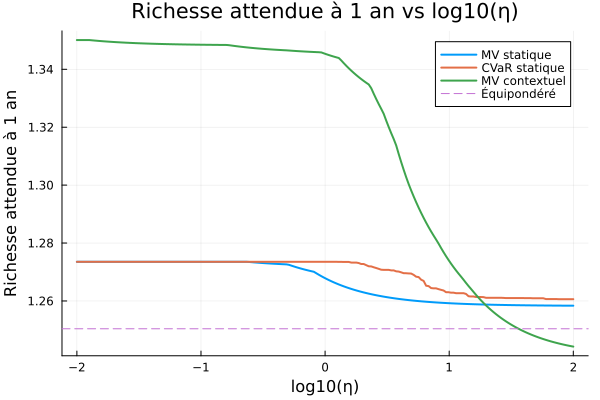

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 3\\outputs_chap3\\chap3_fig3_wealth_vs_eta.png"

In [41]:
#### Cellule 3.17 #######

    #Tracé de la richesse attendue à 1 an en fonction de log10(η)
    # pour les trois stratégies :
       # MV statique
       # CVaR statique
       # MV contextuel
p_eta2 = plot(
    results_chap3.log10η,
    results_chap3.EW1_static,
    label = "MV statique",
    lw = 2,
    xlabel = "log10(η)",
    ylabel = "Richesse attendue à 1 an",
    title = "Richesse attendue à 1 an vs log10(η)"
)

 #Ajout des autres stratégies
plot!(p_eta2,
      results_chap3.log10η,
      results_chap3.EW1_cvar,
      label = "CVaR statique",
      lw = 2)

plot!(p_eta2,
      results_chap3.log10η,
      results_chap3.EW1_ctx,
      label = "MV contextuel",
      lw = 2)

#Ajout du benchmark équipondéré
hline!([EW1_EW],
       label = "Équipondéré",
       linestyle = :dash)

# Affichage
display(p_eta2)

# Sauvegarde
savefig(p_eta2, joinpath(OUTDIR, "chap3_fig3_wealth_vs_eta.png"))

In [43]:
#### Cellule 3.18 ####

  #Choix d’une valeur de η pour la comparaison dynamique des stratégies
     η_plot= 1.0

#Recherche de l’indice correspondant dans la grille
 idx_plot= argmin(abs.(results_chap3.η .- η_plot))

println("η_plot choisi = ", η_plot)
println("η sur la grille le plus proche = ", results_chap3.η[idx_plot])

#Extraction des portefeuilles optimaux pour η_plot
 x_static_plot = vec(X_static[idx_plot, :])
 x_cvar_plot = vec(X_cvar[idx_plot, :])
 x1_plot= vec(X_ctx_r1[idx_plot, :])
 x2_plot= vec(X_ctx_r2[idx_plot, :])
 x3_plot= vec(X_ctx_r3[idx_plot, :])

#Rendements réalisés du portefeuille équipondéré
   rp_EW= R_ctx * xEW
#Rendements réalisés du portefeuille MV statique
rp_static= R_ctx * x_static_plot
#Rendements réalisés du portefeuille CVaR statique
rp_cvar = R_ctx * x_cvar_plot

# Rendements réalisés du portefeuille contextuel :
#à chaque date, on applique le portefeuille correspondant au régime observé
rp_ctx = similar(R_mkt_ctx)
for t in 1:length(regimes)
    if regimes[t] == 1
        rp_ctx[t] = dot(R_ctx[t, :], x1_plot)
    elseif regimes[t] == 2
        rp_ctx[t] = dot(R_ctx[t, :], x2_plot)
    else
        rp_ctx[t] = dot(R_ctx[t, :], x3_plot)
    end
end

#Construction des trajectoires de richesse
   W_EW = wealth_path_log(rp_EW; W0=W0)
   W_static = wealth_path_log(rp_static; W0=W0)
   W_cvar = wealth_path_log(rp_cvar; W0=W0)
   W_ctx = wealth_path_log(rp_ctx; W0=W0)

# Affichage des richesses finales
println("Richesse finale :")
println("EW         = ", W_EW[end])
println("MV statique= ", W_static[end])
println("CVaR       = ", W_cvar[end])
println("Contextuel = ", W_ctx[end])

η_plot choisi = 1.0
η sur la grille le plus proche = 0.9771241535346498
Richesse finale :
EW         = 11.416558483650897
MV statique= 13.305094409761884
CVaR       = 13.939304850596706
Contextuel = 25.377971284601927


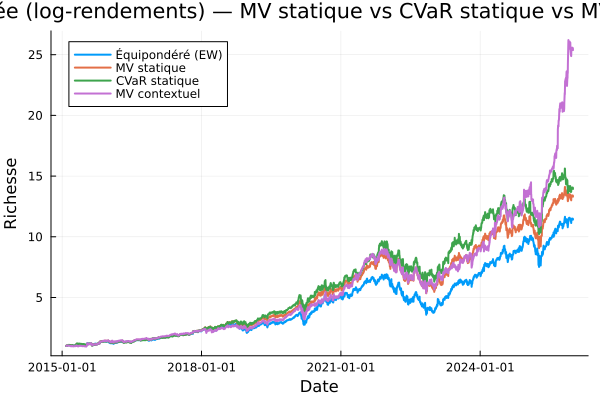

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 3\\outputs_chap3\\chap3_fig4_wealth_path.png"

In [45]:
#### Cellule 3.19 #######

  #Tracé des trajectoires de richesse réalisée
  #pour les différentes stratégies :
     # Équipondéré (benchmark)
     # MV statique
     # CVaR statique
     # MV contextuel
pW1 = plot(
    dates_ctx, W_EW,
    label = "Équipondéré (EW)",
    lw = 2,
    xlabel = "Date",
    ylabel = "Richesse",
    title = "Richesse réalisée (log-rendements) — MV statique vs CVaR statique vs MV contextuel vs EW"
)

# Ajout des autres stratégies
plot!(pW1, dates_ctx, W_static, label = "MV statique", lw = 2)
plot!(pW1, dates_ctx, W_cvar,   label = "CVaR statique", lw = 2)
plot!(pW1, dates_ctx, W_ctx,    label = "MV contextuel", lw = 2)

# Affichage
display(pW1)

# Sauvegarde de la figure
savefig(pW1, joinpath(OUTDIR, "chap3_fig4_wealth_path.png"))

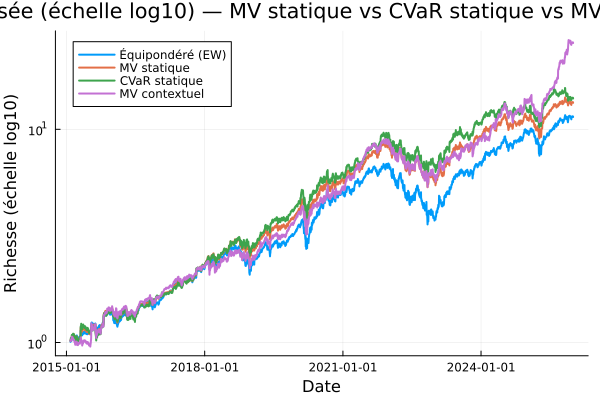

"C:\\Users\\User\\Desktop\\Mémoiremaîtrise udeM\\Les codes du mémoires de Maitrise UdeM\\Codes Chapitre 3\\outputs_chap3\\chap3_fig5_wealth_path_log10.png"

In [49]:
#### Cellule 3.20 ####

   # Tracé des trajectoires de richesse réalisée en échelle logarithmique (log10)
    # Cette représentation permet de mieux comparer les taux de croissance
     #des différentes stratégies dans le temps
pW2 = plot(
    dates_ctx, W_EW,
    label = "Équipondéré (EW)",
    lw = 2,
    yscale = :log10,
    xlabel = "Date",
    ylabel = "Richesse (échelle log10)",
    title = "Richesse réalisée (échelle log10) — MV statique vs CVaR statique vs MV contextuel vs EW"
)

# Ajout des autres stratégies
plot!(pW2, dates_ctx, W_static, label = "MV statique", lw = 2)
plot!(pW2, dates_ctx, W_cvar,   label = "CVaR statique", lw = 2)
plot!(pW2, dates_ctx, W_ctx,    label = "MV contextuel", lw = 2)
# Affichage
display(pW2)
# Sauvegarde de la figure
savefig(pW2, joinpath(OUTDIR, "chap3_fig5_wealth_path_log10.png"))

In [51]:
#### Cellule 3.21 ####

    # Construction d’un tableau comparatif des stratégies
    #basé sur :
        # le rendement annualisé réalisé
        # la richesse finale observée

comparison = DataFrame(
    Portefeuille = ["MV statique", "CVaR statique", "MV contextuel", "Équipondéré"],

    # Rendement annualisé estimé à partir des rendements réalisés
    ER_ann = [
        mean(rp_static) * FREQ,
        mean(rp_cvar) * FREQ,
        mean(rp_ctx) * FREQ,
        mean(rp_EW) * FREQ
    ],
    # Richesse finale atteinte par chaque stratégie
    Wealth_finale = [
        W_static[end],
        W_cvar[end],
        W_ctx[end],
        W_EW[end]
    ]
)

# Affichage du tableau
println("Tableau comparatif :")
println(comparison)

Tableau comparatif :
4×3 DataFrame
 Row │ Portefeuille   ER_ann    Wealth_finale 
     │ String         Float64   Float64       
─────┼────────────────────────────────────────
   1 │ MV statique    0.237514        13.3051
   2 │ CVaR statique  0.241787        13.9393
   3 │ MV contextuel  0.296773        25.378
   4 │ Équipondéré    0.223466        11.4166


SYNTHÈSE : PERFORMANCE FINALE DE LA MÉTHODE CONTEXTUELLE

Nombre total de valeurs de η analysées : 200

Valeurs de η où la méthode contextuelle surperforme toutes les autres :
[0.01, 0.0104737, 0.0109699, 0.0114895, 0.0120338, 0.0126038, 0.0132009, 0.0138262, 0.0144812, 0.0151672, 0.0158857, 0.0166382, 0.0174263, 0.0182518, 0.0191164, 0.020022, 0.0209705, 0.0219639, 0.0230043, 0.024094, 0.0252354, 0.0264308, 0.0276829, 0.0289942, 0.0303677, 0.0318063, 0.0333129, 0.034891, 0.0365438, 0.0382749, 0.0400881, 0.0419871, 0.043976, 0.0460592, 0.0482411, 0.0505263, 0.0529198, 0.0554266, 0.0580523, 0.0608022, 0.0636825, 0.0666992, 0.0698588, 0.0731681, 0.0766341, 0.0802643, 0.0840665, 0.0880488, 0.0922198, 0.0965883, 0.101164, 0.105956, 0.110975, 0.116232, 0.121738, 0.127505, 0.133545, 0.139871, 0.146497, 0.153437, 0.160705, 0.168318, 0.176291, 0.184642, 0.193389, 0.20255, 0.212145, 0.222195, 0.23272, 0.243744, 0.255291, 0.267384, 0.28005, 0.293317, 0.307211, 0.321764, 0.337006, 0.352971, 0.369

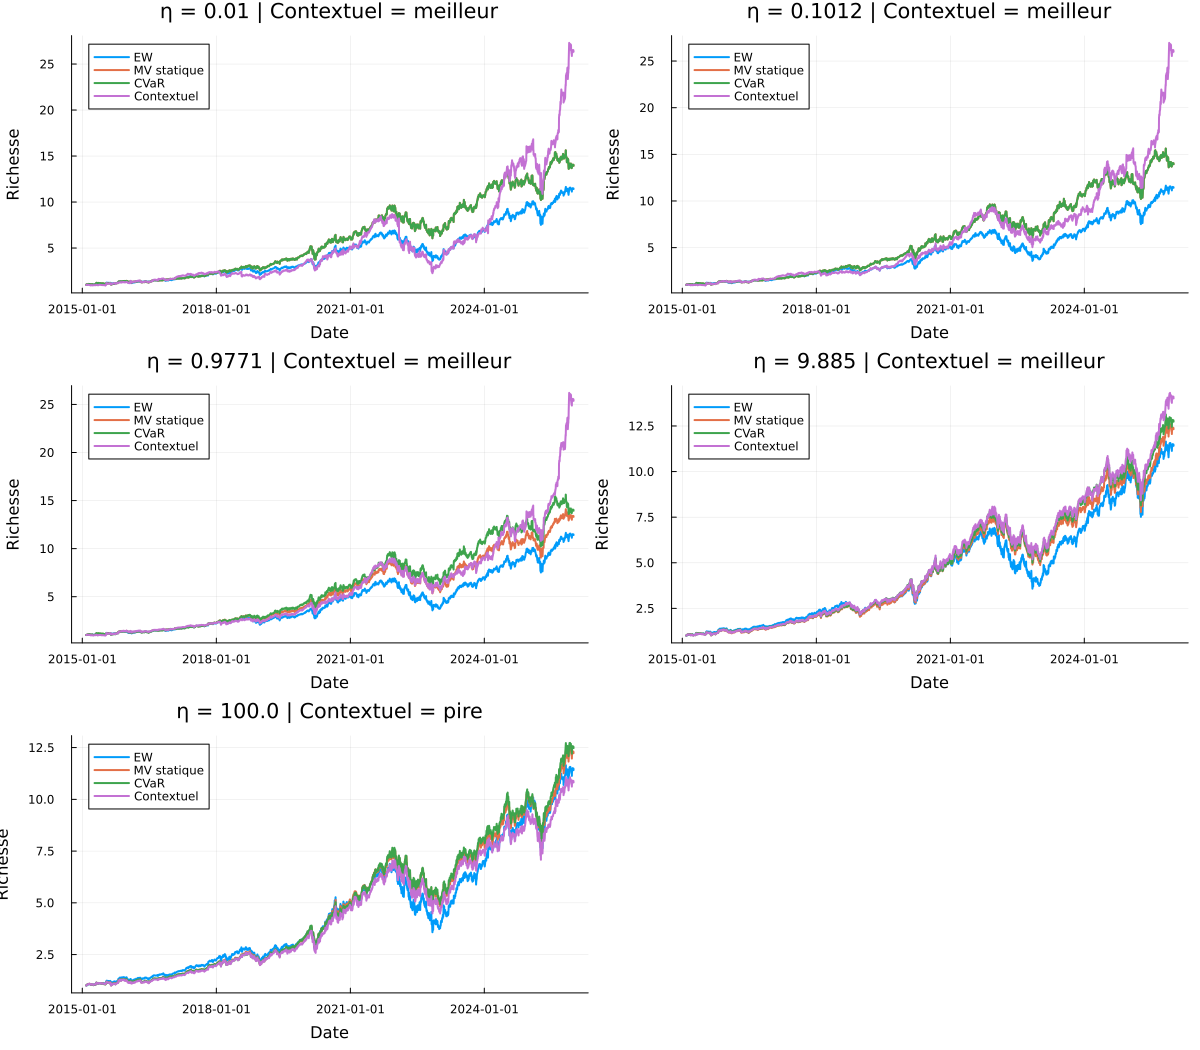

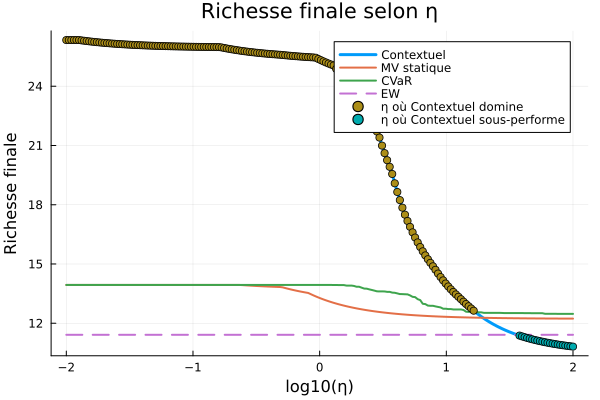


Tableau récapitulatif sauvegardé dans : outputs_chap3\chap3_summary_contextual_vs_others.csv
Figures sauvegardées dans : outputs_chap3


In [53]:
#### Cellule 3.22 ####

begin
    # Chargement des bibliothèques nécessaires
    using DataFrames, Statistics, LinearAlgebra, Printf, Plots

    # Valeurs de η à illustrer plus en détail
    η_show = [0.01, 0.1, 1.0, 10.0, 100.0]

    # Indicateur pour activer la sauvegarde des figures
    save_figures = true

    # Fonction utilitaire : indice de la valeur la plus proche dans un vecteur
    nearest_index(v::AbstractVector{<:Real}, a::Real) = argmin(abs.(v .- a))

    # Fonction de calcul des rendements contextuels :
    # à chaque date, on applique le portefeuille correspondant au régime observé
    function contextual_returns(R_ctx, regimes, x1, x2, x3)
        rp = similar(vec(mean(R_ctx, dims=2)))
        for t in 1:length(regimes)
            if regimes[t] == 1
                rp[t] = dot(R_ctx[t, :], x1)
            elseif regimes[t] == 2
                rp[t] = dot(R_ctx[t, :], x2)
            else
                rp[t] = dot(R_ctx[t, :], x3)
            end
        end
        return rp
    end

    # Vérifications minimales :
    # on s'assure que les objets nécessaires existent déjà
    @assert @isdefined(η_grid) "η_grid n'existe pas."
    @assert @isdefined(X_static) "X_static n'existe pas."
    @assert @isdefined(X_cvar) "X_cvar n'existe pas."
    @assert @isdefined(X_ctx_r1) "X_ctx_r1 n'existe pas."
    @assert @isdefined(X_ctx_r2) "X_ctx_r2 n'existe pas."
    @assert @isdefined(X_ctx_r3) "X_ctx_r3 n'existe pas."
    @assert @isdefined(R_ctx) "R_ctx n'existe pas."
    @assert @isdefined(dates_ctx) "dates_ctx n'existe pas."
    @assert @isdefined(regimes) "regimes n'existe pas."
    @assert @isdefined(xEW) "xEW n'existe pas."
    @assert @isdefined(wealth_path_log) "wealth_path_log n'existe pas."

    # Nombre total de valeurs de η
    nη = length(η_grid)

    # Vecteurs de stockage des performances finales
    finalW_static = zeros(nη)
    finalW_cvar   = zeros(nη)
    finalW_ctx    = zeros(nη)
    finalW_ew     = zeros(nη)

    ER_static = zeros(nη)
    ER_cvar   = zeros(nη)
    ER_ctx    = zeros(nη)
    ER_ew     = zeros(nη)

    # Performance du benchmark équipondéré
    rp_ew = R_ctx * xEW
    W_ew = wealth_path_log(rp_ew; W0=W0)
    ew_final = W_ew[end]
    ew_er_ann = mean(rp_ew) * FREQ

    # Calcul complet sur toute la grille de η
    for k in 1:nη
        x_static = vec(X_static[k, :])
        x_cvar   = vec(X_cvar[k, :])
        x1       = vec(X_ctx_r1[k, :])
        x2       = vec(X_ctx_r2[k, :])
        x3       = vec(X_ctx_r3[k, :])

        rp_static = R_ctx * x_static
        rp_cvar   = R_ctx * x_cvar
        rp_ctx    = contextual_returns(R_ctx, regimes, x1, x2, x3)

        W_static = wealth_path_log(rp_static; W0=W0)
        W_cvar   = wealth_path_log(rp_cvar;   W0=W0)
        W_ctx    = wealth_path_log(rp_ctx;    W0=W0)

        finalW_static[k] = W_static[end]
        finalW_cvar[k]   = W_cvar[end]
        finalW_ctx[k]    = W_ctx[end]
        finalW_ew[k]     = ew_final

        ER_static[k] = mean(rp_static) * FREQ
        ER_cvar[k]   = mean(rp_cvar) * FREQ
        ER_ctx[k]    = mean(rp_ctx) * FREQ
        ER_ew[k]     = ew_er_ann
    end

    # Construction du tableau récapitulatif
    summary_df = DataFrame(
        η = η_grid,
        log10η = log10.(η_grid),
        W_final_contextuel = finalW_ctx,
        W_final_statique = finalW_static,
        W_final_cvar = finalW_cvar,
        W_final_ew = finalW_ew,
        ER_ann_contextuel = ER_ctx,
        ER_ann_statique = ER_static,
        ER_ann_cvar = ER_cvar,
        ER_ann_ew = ER_ew
    )

    # Écarts de performance de la méthode contextuelle
    summary_df.Contextuel_vs_Statique = summary_df.W_final_contextuel .- summary_df.W_final_statique
    summary_df.Contextuel_vs_CVaR     = summary_df.W_final_contextuel .- summary_df.W_final_cvar
    summary_df.Contextuel_vs_EW       = summary_df.W_final_contextuel .- summary_df.W_final_ew

    # Rang de la méthode contextuelle parmi les 4 stratégies
    ctx_rank = Vector{Int}(undef, nη)
    for k in 1:nη
        vals = [
            finalW_ctx[k],
            finalW_static[k],
            finalW_cvar[k],
            finalW_ew[k]
        ]
        ctx_rank[k] = findfirst(isequal(1), sortperm(vals; rev=true))
    end
    summary_df.Rang_contextuel = ctx_rank

    # Sous-ensembles utiles pour l'analyse
    idx_ctx_best_all = findall(
        (finalW_ctx .>= finalW_static) .&
        (finalW_ctx .>= finalW_cvar)   .&
        (finalW_ctx .>= finalW_ew)
    )

    idx_ctx_worse_all = findall(
        (finalW_ctx .<= finalW_static) .&
        (finalW_ctx .<= finalW_cvar)   .&
        (finalW_ctx .<= finalW_ew)
    )

    idx_ctx_beats_static = findall(finalW_ctx .> finalW_static)
    idx_ctx_beats_cvar   = findall(finalW_ctx .> finalW_cvar)
    idx_ctx_beats_ew     = findall(finalW_ctx .> finalW_ew)

    # Affichage des diagnostics principaux
    println("==============================================================")
    println("SYNTHÈSE : PERFORMANCE FINALE DE LA MÉTHODE CONTEXTUELLE")
    println("==============================================================")

    println("\nNombre total de valeurs de η analysées : ", nη)

    println("\nValeurs de η où la méthode contextuelle surperforme toutes les autres :")
    if isempty(idx_ctx_best_all)
        println("Aucune.")
    else
        println(round.(η_grid[idx_ctx_best_all], sigdigits=6))
    end

    println("\nValeurs de η où la méthode contextuelle sous-performe toutes les autres :")
    if isempty(idx_ctx_worse_all)
        println("Aucune.")
    else
        println(round.(η_grid[idx_ctx_worse_all], sigdigits=6))
    end

    println("\nValeurs de η où la méthode contextuelle bat la méthode statique :")
    if isempty(idx_ctx_beats_static)
        println("Aucune.")
    else
        println(round.(η_grid[idx_ctx_beats_static], sigdigits=6))
    end

    println("\nValeurs de η où la méthode contextuelle bat la méthode CVaR :")
    if isempty(idx_ctx_beats_cvar)
        println("Aucune.")
    else
        println(round.(η_grid[idx_ctx_beats_cvar], sigdigits=6))
    end

    println("\nValeurs de η où la méthode contextuelle bat l’équipondéré :")
    if isempty(idx_ctx_beats_ew)
        println("Aucune.")
    else
        println(round.(η_grid[idx_ctx_beats_ew], sigdigits=6))
    end

    # Meilleur et pire η pour la stratégie contextuelle
    idx_best_ctx = argmax(finalW_ctx)
    idx_worst_ctx = argmin(finalW_ctx)

    println("\nMeilleur η pour la méthode contextuelle (selon richesse finale) :")
    println("η = ", round(η_grid[idx_best_ctx], sigdigits=6),
            " | richesse finale = ", round(finalW_ctx[idx_best_ctx], sigdigits=6))

    println("\nPire η pour la méthode contextuelle (selon richesse finale) :")
    println("η = ", round(η_grid[idx_worst_ctx], sigdigits=6),
            " | richesse finale = ", round(finalW_ctx[idx_worst_ctx], sigdigits=6))

    # Sélection de quelques valeurs représentatives de η pour visualisation
    idx_show = [nearest_index(η_grid, η) for η in η_show]
    η_eff = η_grid[idx_show]

    nplots = length(idx_show)
    ncols = 2
    nrows = ceil(Int, nplots / ncols)

    plist = Plots.Plot[]

    # Figures de richesse réalisée pour quelques η choisis
    for idx in idx_show
        ηv = η_grid[idx]

        x_static = vec(X_static[idx, :])
        x_cvar   = vec(X_cvar[idx, :])
        x1       = vec(X_ctx_r1[idx, :])
        x2       = vec(X_ctx_r2[idx, :])
        x3       = vec(X_ctx_r3[idx, :])

        rp_static = R_ctx * x_static
        rp_cvar   = R_ctx * x_cvar
        rp_ctx    = contextual_returns(R_ctx, regimes, x1, x2, x3)

        W_static = wealth_path_log(rp_static; W0=W0)
        W_cvar   = wealth_path_log(rp_cvar;   W0=W0)
        W_ctx    = wealth_path_log(rp_ctx;    W0=W0)

        rank_label =
            if finalW_ctx[idx] >= finalW_static[idx] && finalW_ctx[idx] >= finalW_cvar[idx] && finalW_ctx[idx] >= finalW_ew[idx]
                "Contextuel = meilleur"
            elseif finalW_ctx[idx] <= finalW_static[idx] && finalW_ctx[idx] <= finalW_cvar[idx] && finalW_ctx[idx] <= finalW_ew[idx]
                "Contextuel = pire"
            else
                "Contextuel = intermédiaire"
            end

        p = plot(
            dates_ctx, W_ew,
            label = "EW",
            lw = 2,
            xlabel = "Date",
            ylabel = "Richesse",
            title = "η = $(round(ηv, sigdigits=4)) | $rank_label"
        )
        plot!(p, dates_ctx, W_static, label = "MV statique", lw = 2)
        plot!(p, dates_ctx, W_cvar,   label = "CVaR", lw = 2)
        plot!(p, dates_ctx, W_ctx,    label = "Contextuel", lw = 2)

        push!(plist, p)
    end

    # Figure multi-panneaux
    pgrid = plot(plist..., layout=(nrows, ncols), size=(1200, 350*nrows))
    display(pgrid)

    if save_figures
        savefig(pgrid, joinpath(OUTDIR, "chap3_fig_multi_eta_wealth_paths.png"))
    end

    # Figure synthétique : richesse finale selon η
    p_final = plot(
        log10.(η_grid), finalW_ctx,
        lw = 3,
        label = "Contextuel",
        xlabel = "log10(η)",
        ylabel = "Richesse finale",
        title = "Richesse finale selon η"
    )
    plot!(p_final, log10.(η_grid), finalW_static, lw = 2, label = "MV statique")
    plot!(p_final, log10.(η_grid), finalW_cvar,   lw = 2, label = "CVaR")
    plot!(p_final, log10.(η_grid), finalW_ew,     lw = 2, linestyle = :dash, label = "EW")

    scatter!(p_final, log10.(η_grid[idx_ctx_best_all]), finalW_ctx[idx_ctx_best_all],
             markersize = 4, label = "η où Contextuel domine")

    scatter!(p_final, log10.(η_grid[idx_ctx_worse_all]), finalW_ctx[idx_ctx_worse_all],
             markersize = 4, label = "η où Contextuel sous-performe")

    display(p_final)

    if save_figures
        savefig(p_final, joinpath(OUTDIR, "chap3_fig_contextual_dominance_vs_eta.png"))
    end

    # Sauvegarde du tableau récapitulatif
    CSV.write(joinpath(OUTDIR, "chap3_summary_contextual_vs_others.csv"), summary_df)

    println("\nTableau récapitulatif sauvegardé dans : ",
            joinpath(OUTDIR, "chap3_summary_contextual_vs_others.csv"))
    println("Figures sauvegardées dans : ", OUTDIR)

    nothing
end